<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/Galaxy_clean_up_and_new_CMD_10012026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installation (execute only if running on a cloud platform!)¶

In [1]:
# -- Use the following line for google colab removing the hash at the beginning.
! pip install -q 'corner==2.2.2' 'bilby==2.2.2' 'astropy==6.0.1'

## Initialization

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import corner

In [3]:
!pip install healpy astropy pyvo pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 41.6 MB/s eta 0:00:00


In [4]:
# REQUIREMENTS (already used in notebook):
# !pip install pyvo astropy healpy pandas

import json, numpy as np, pandas as pd, healpy as hp
from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u

# ---------- Config ----------
TAP_URL = "https://datalab.noirlab.edu/tap"
SKYMAP_URL = "https://dcc.ligo.org/LIGO-P2000230/public/GW190814_skymap.fits.gz"
CREDIBLE = 0.90
SQL_FATAL_QUALITY = True          # keep True to avoid multi-million row downloads
MAG_MIN, MAG_MAX = 16.0, 24.5     # light magnitude guard for tractability
NSIDE_FORCE = None                # set to an int to override skymap NSIDE if needed (usually None)
NEST_FORCE  = None                # set to True/False to override, else read from skymap

Z_MIN, Z_MAX = 0.043, 0.061       # from GW distance ~ 200–280 Mpc

from pyvo import dal as vo

svc = vo.TAPService(TAP_URL)

# ---------- Helpers ----------
def hpd_threshold(prob, level):
    flat = prob.ravel()
    order = np.argsort(flat)[::-1]
    csum = np.cumsum(flat[order])
    return flat[order[np.searchsorted(csum, level * flat.sum())]]

def healpix_components(mask, nside, nest=True):
    npix = mask.size
    visited = np.zeros(npix, bool)
    comps = []
    idxs = np.where(mask)[0]
    idxset = set(idxs.tolist())
    for s in idxs:
        if visited[s]: continue
        q=[int(s)]; visited[s]=True; comp=[int(s)]
        while q:
            p=q.pop()
            neigh = hp.get_all_neighbours(nside, p, nest=nest)
            for nb in neigh[neigh>=0]:
                if (nb in idxset) and (not visited[nb]):
                    visited[nb]=True; q.append(int(nb)); comp.append(int(nb))
        comps.append(comp)
    return comps

def minimal_ra_span(ra_deg):
    ra = np.mod(ra_deg, 360.0)
    s = np.sort(ra); dbl = np.concatenate([s, s+360])
    N=len(s); best=(1e9,0,0)
    for i in range(N):
        j=i+N-1
        w=dbl[j]-dbl[i]
        if w<best[0]:
            a=(dbl[i])%360.0; b=(a+w)%360.0; best=(w,a,b)
    return best[1], best[2]

# ---------- 1) Load skymap & build 90% main island ----------
with fits.open(SKYMAP_URL, memmap=True) as h:
    tab = h[1].data; hdr = h[1].header
    prob      = np.asarray(tab["PROB"], float)
    distmu    = np.asarray(tab["DISTMU"], float)
    distsigma = np.asarray(tab["DISTSIGMA"], float)
    nside = int(hdr["NSIDE"]) if NSIDE_FORCE is None else int(NSIDE_FORCE)
    nest  = hdr.get("ORDERING","NESTED").upper().startswith("NEST") if NEST_FORCE is None else bool(NEST_FORCE)

thr  = hpd_threshold(prob, CREDIBLE)
mask = prob >= thr
comps = healpix_components(mask, nside, nest=nest)
main  = np.array(comps[np.argmax([prob[c].sum() for c in comps])], dtype=int)

theta, phi = hp.pix2ang(nside, main, nest=nest)
dec_deg = 90.0 - np.degrees(theta)
ra_deg  = np.degrees(phi) % 360.0
dec_min, dec_max = float(dec_deg.min()), float(dec_deg.max())
ra_min, ra_max   = minimal_ra_span(ra_deg)

funnel = {}

# ---------- 2) SQL rectangle query (DES main ⨝ y6_gold), fatal-only limits ----------
# We *do not* apply morphology or photo-z in SQL to preserve the funnel order.
where_sky = f"""
(g.ra BETWEEN {ra_min} AND {ra_max}) AND
(g.dec BETWEEN {dec_min} AND {dec_max})
"""

where_quality = "1=1"
if SQL_FATAL_QUALITY:
    where_quality = f"(g.flags_i < 4) AND (g.mag_auto_i BETWEEN {MAG_MIN} AND {MAG_MAX})"

adql = f"""
SELECT
  g.coadd_object_id AS coadd_object_id,
  g.ra, g.dec,
  g.mag_auto_i, g.flags_i,
  y.dnf_z,
  y.wavg_spread_model_z, y.wavg_spreaderr_model_z,
  y.spread_model_z,      y.spreaderr_model_z
FROM des_dr2.main AS g
JOIN des_dr2.y6_gold AS y
  ON g.coadd_object_id = y.coadd_object_id
WHERE
  {where_sky}
  AND {where_quality}
"""

rect_tbl = svc.search(adql).to_table()
funnel["step1_rectangle_sql"] = int(len(rect_tbl))

print(f"[1] Rectangle (SQL) — rows: {funnel['step1_rectangle_sql']}  "
      f"[flags_i<4={SQL_FATAL_QUALITY}, mag {MAG_MIN}–{MAG_MAX}]")

# ---------- 3) Exact 90% main-island mask ----------
theta = np.radians(90.0 - np.array(rect_tbl["dec"]))
phi   = np.radians(np.array(rect_tbl["ra"]) % 360.0)
pix   = hp.ang2pix(nside, theta, phi, nest=nest)
in_island = np.isin(pix, main)
island_tbl = rect_tbl[in_island]
funnel["step2_inside_island"] = int(len(island_tbl))
print(f"[2] Inside exact 90% main island — rows: {funnel['step2_inside_island']}")

# ---------- 4) Morphology (galaxy-like) ----------
wok = (island_tbl["wavg_spread_model_z"] > -98) & (island_tbl["wavg_spreaderr_model_z"] > -98)
m3  = np.where(
    wok,
    island_tbl["wavg_spread_model_z"] + 3*island_tbl["wavg_spreaderr_model_z"],
    island_tbl["spread_model_z"]      + 3*island_tbl["spreaderr_model_z"]
)
gal_mask = m3 > 0.005
gal_tbl  = island_tbl[gal_mask]
funnel["step3_morph_galaxies"] = int(len(gal_tbl))
print(f"[3] Morphology (extended) — rows: {funnel['step3_morph_galaxies']}")

# ---------- 5) Photo-z window (distance slice) ----------
z_ok = (gal_tbl["dnf_z"] >= Z_MIN) & (gal_tbl["dnf_z"] <= Z_MAX)
final_tbl = gal_tbl[z_ok]
funnel["step4_photoz_window"] = int(len(final_tbl))
print(f"[4] Photo-z in [{Z_MIN},{Z_MAX}] — rows: {funnel['step4_photoz_window']}")

# ---------- Save artifacts ----------
# CSV + FITS of final candidates
final_df = final_tbl.to_pandas()
final_df.to_csv("GW190814_candidates_90pct.csv", index=False)
final_tbl.write("GW190814_candidates_90pct.fits", overwrite=True)

# Counts JSON + metadata
meta = {
    "event": "GW190814",
    "credible_level": CREDIBLE,
    "main_island_prob_mass": float(prob[main].sum()),
    "nside": nside, "nest": nest,
    "ra_min_deg": ra_min, "ra_max_deg": ra_max,
    "dec_min_deg": dec_min, "dec_max_deg": dec_max,
    "sql_fatal_quality": SQL_FATAL_QUALITY,
    "mag_range_i": [MAG_MIN, MAG_MAX],
    "z_window": [Z_MIN, Z_MAX]
}
out = {"counts": funnel, "meta": meta}
with open("GW190814_funnel_counts.json", "w") as f:
    json.dump(out, f, indent=2)

print("\nSaved:")
print(" - GW190814_candidates_90pct.csv")
print(" - GW190814_candidates_90pct.fits")
print(" - GW190814_funnel_counts.json")


[1] Rectangle (SQL) — rows: 2119644  [flags_i<4=True, mag 16.0–24.5]
[2] Inside exact 90% main island — rows: 1393743
[3] Morphology (extended) — rows: 1321738


[4] Photo-z in [0.043,0.061] — rows: 589

Saved:
 - GW190814_candidates_90pct.csv
 - GW190814_candidates_90pct.fits
 - GW190814_funnel_counts.json


In [5]:
# Crossmatch your 589 DES candidates to GLADE (GLADE+) via VizieR (robust)
# Outputs:
#  - GW190814_DES_vs_GLADE_matches_2arcsec.csv
#  - GW190814_DES_candidates_not_in_GLADE_2arcsec.csv

# ---------- deps ----------
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["astroquery", "astropy", "pandas", "numpy"]:
    pip_install(p)

import pandas as pd, numpy as np
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.vizier import Vizier

# ---------- inputs ----------
des_csv = "/content/GW190814_candidates_90pct.csv"     # your 589-list
# 90% main-island rectangle (deg) – from your funnel run
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

margin_deg   = 0.15          # safety border around the box
match_radius = 2.0 * u.arcsec

# ---------- load DES candidates ----------
des_df = pd.read_csv(des_csv)
if not {"ra","dec"}.issubset({c.lower() for c in des_df.columns}):
    raise ValueError("Expected columns 'ra' and 'dec' in the CSV.")
des_tab = Table.from_pandas(des_df)

# ---------- find a GLADE catalog on this VizieR mirror ----------
cats = Vizier.find_catalogs("GLADE")
if not cats:
    raise RuntimeError("No GLADE entries found on this VizieR mirror.")
# Prefer the collection key containing 'VII/281' (GLADE+), else take any GLADE entry
preferred = [k for k in cats.keys() if "VII/281" in k]
cat_id = preferred[0] if preferred else list(cats.keys())[0]
print("Using catalog id:", cat_id)

# ---------- discover RA/Dec column names ----------
Vizier.ROW_LIMIT = 50
sample = None
try:
    sample = Vizier.get_catalogs(cat_id)[0]   # sometimes returns metadata table
except Exception:
    pass
# try a tiny region to get real columns if needed
if sample is None or len(sample.colnames) == 0:
    try:
        tiny = Vizier.query_region(SkyCoord(0*u.deg, 0*u.deg), width=0.1*u.deg, height=0.1*u.deg, catalog=cat_id)
        if len(tiny) > 0:
            sample = tiny[0]
    except Exception:
        pass

if sample is None:
    raise RuntimeError("Could not inspect columns for the chosen GLADE catalog.")

ra_candidates  = ["RAJ2000","RA_ICRS","_RAJ2000","raj2000","ra"]
dec_candidates = ["DEJ2000","DE_ICRS","_DEJ2000","dej2000","dec"]
cols_lower = {c.lower(): c for c in sample.colnames}

def pick_name(cands):
    for c in cands:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    return None

glade_ra  = pick_name(ra_candidates)
glade_dec = pick_name(dec_candidates)
if glade_ra is None or glade_dec is None:
    raise RuntimeError(f"Could not find RA/Dec column names. Columns seen: {sample.colnames}")
print("GLADE RA/Dec columns:", glade_ra, glade_dec)

# ---------- region query for our rectangle (+ margin) ----------
Vizier.ROW_LIMIT = -1
Vizier.columns = [glade_ra, glade_dec, "Name", "z", "Dist", "DistErr"]

ra_c  = 0.5*(ra_min + ra_max)
dec_c = 0.5*(dec_min + dec_max)
width =  (ra_max - ra_min) + 2*margin_deg
height = (dec_max - dec_min) + 2*margin_deg
center = SkyCoord(ra=ra_c*u.deg, dec=dec_c*u.deg, frame="icrs")

res = Vizier.query_region(center, width=width*u.deg, height=height*u.deg, catalog=cat_id)
if len(res) == 0 or len(res[0]) == 0:
    # last-chance: expand box slightly more
    res = Vizier.query_region(center, width=(width+0.4)*u.deg, height=(height+0.4)*u.deg, catalog=cat_id)
if len(res) == 0 or len(res[0]) == 0:
    raise RuntimeError("VizieR returned no GLADE rows in this region after expansion.")

glade_tab = res[0]
print(f"GLADE rows retrieved in box: {len(glade_tab)}")

# ---------- robust SkyCoord creation for GLADE RA/Dec ----------
def make_glade_sky(tab, ra_name, dec_name):
    ra_col, dec_col = tab[ra_name], tab[dec_name]
    # try plain floats in degrees
    try:
        ra_deg  = np.array(ra_col, dtype=float)
        dec_deg = np.array(dec_col, dtype=float)
        return SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    except Exception:
        pass
    # try sexagesimal strings as degrees
    try:
        return SkyCoord(ra=ra_col, dec=dec_col, unit=(u.deg, u.deg), frame="icrs")
    except Exception:
        pass
    # fall back to hourangle for RA, degrees for Dec
    return SkyCoord(ra=ra_col, dec=dec_col, unit=(u.hourangle, u.deg), frame="icrs")

des_sky   = SkyCoord(ra=des_tab["ra"]*u.deg,       dec=des_tab["dec"]*u.deg,       frame="icrs")
glade_sky = make_glade_sky(glade_tab, glade_ra, glade_dec)

# ---------- local 2″ nearest-neighbour crossmatch ----------
idx, sep2d, _ = des_sky.match_to_catalog_sky(glade_sky)
matched_mask  = sep2d < match_radius

matched_des   = des_tab[matched_mask]
matched_glade = glade_tab[idx[matched_mask]]
matched       = hstack([matched_des, matched_glade])

unmatched = des_tab[~matched_mask]

# ---------- report & save ----------
n_total    = len(des_tab)
n_matched  = len(matched)
n_unmatched= len(unmatched)
pct        = round(100.0 * n_matched / n_total, 2)

print({
    "total_DES_candidates": n_total,
    "matched_in_GLADE": n_matched,
    "unmatched": n_unmatched,
    "completeness_percent": pct,
    "match_radius_arcsec": float(match_radius.to_value(u.arcsec)),
    "glade_rows_in_box": len(glade_tab),
    "catalog_id_used": cat_id,
    "glade_ra_col": glade_ra,
    "glade_dec_col": glade_dec
})

matched.to_pandas().to_csv("GW190814_DES_vs_GLADE_matches_2arcsec.csv", index=False)
unmatched.to_pandas().to_csv("GW190814_DES_candidates_not_in_GLADE_2arcsec.csv", index=False)
print("Saved:")
print(" - GW190814_DES_vs_GLADE_matches_2arcsec.csv")
print(" - GW190814_DES_candidates_not_in_GLADE_2arcsec.csv")


Using catalog id: VII/281
GLADE RA/Dec columns: RAJ2000 DEJ2000
GLADE rows retrieved in box: 2739
{'total_DES_candidates': 589, 'matched_in_GLADE': 95, 'unmatched': 494, 'completeness_percent': 16.13, 'match_radius_arcsec': 2.0, 'glade_rows_in_box': 2739, 'catalog_id_used': 'VII/281', 'glade_ra_col': 'RAJ2000', 'glade_dec_col': 'DEJ2000'}
Saved:
 - GW190814_DES_vs_GLADE_matches_2arcsec.csv
 - GW190814_DES_candidates_not_in_GLADE_2arcsec.csv


In [6]:
# Completeness sweep for GLADE matches: 2", 3", 5" + brightness comparison at 2"

import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["astroquery", "astropy", "pandas", "numpy"]:
    pip_install(p)

import pandas as pd, numpy as np
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.vizier import Vizier

# ---------- Inputs ----------
des_csv = "/content/GW190814_candidates_90pct.csv"
# your 90% main-island rectangle (deg)
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484
margin_deg = 0.15  # small buffer

# ---------- Load 589 DES candidates ----------
des = Table.read(des_csv, format="ascii.csv")
if not {"ra","dec"}.issubset(set(des.colnames)):
    raise ValueError("CSV must have 'ra' and 'dec' columns.")
des_sky = SkyCoord(des["ra"].astype(float)*u.deg, des["dec"].astype(float)*u.deg, frame="icrs")

# ---------- Ensure we have a GLADE subset (reuse prior glade_tab if available) ----------
def get_glade_subset():
    global glade_tab, glade_ra, glade_dec
    try:
        glade_tab, glade_ra, glade_dec  # type: ignore
        if len(glade_tab) > 0:
            return
    except Exception:
        pass
    cats = Vizier.find_catalogs("GLADE")
    if not cats:
        raise RuntimeError("No GLADE entries found on this VizieR mirror.")
    preferred = [k for k in cats.keys() if "VII/281" in k]
    cat_id = preferred[0] if preferred else list(cats.keys())[0]
    Vizier.ROW_LIMIT = 50
    sample = None
    try:
        sample = Vizier.get_catalogs(cat_id)[0]
    except Exception:
        pass
    if sample is None or len(sample.colnames) == 0:
        tiny = Vizier.query_region(SkyCoord(0*u.deg,0*u.deg), width=0.1*u.deg, height=0.1*u.deg, catalog=cat_id)
        sample = tiny[0] if (len(tiny)>0) else None
    if sample is None:
        raise RuntimeError("Could not inspect columns for GLADE.")
    ra_candidates  = ["RAJ2000","RA_ICRS","_RAJ2000","raj2000","ra"]
    dec_candidates = ["DEJ2000","DE_ICRS","_DEJ2000","dej2000","dec"]
    cols_lower = {c.lower(): c for c in sample.colnames}
    def pick(cands):
        for c in cands:
            if c.lower() in cols_lower:
                return cols_lower[c.lower()]
        return None
    glade_ra  = pick(ra_candidates)
    glade_dec = pick(dec_candidates)
    if glade_ra is None or glade_dec is None:
        raise RuntimeError(f"Could not find RA/Dec columns in GLADE. Columns={sample.colnames}")

    Vizier.ROW_LIMIT = -1
    ra_c  = 0.5*(ra_min + ra_max)
    dec_c = 0.5*(dec_min + dec_max)
    width =  (ra_max - ra_min) + 2*margin_deg
    height = (dec_max - dec_min) + 2*margin_deg
    center = SkyCoord(ra=ra_c*u.deg, dec=dec_c*u.deg, frame="icrs")
    res = Vizier.query_region(center, width=width*u.deg, height=height*u.deg, catalog=cat_id)
    if len(res)==0 or len(res[0])==0:
        res = Vizier.query_region(center, width=(width+0.4)*u.deg, height=(height+0.4)*u.deg, catalog=cat_id)
    if len(res)==0 or len(res[0])==0:
        raise RuntimeError("VizieR returned no GLADE rows in this region.")
    glade_tab = res[0]
    # expose names in globals
    globals()["glade_tab"] = glade_tab
    globals()["glade_ra"]  = glade_ra
    globals()["glade_dec"] = glade_dec
    print(f"GLADE rows retrieved in box: {len(glade_tab)} (RA={glade_ra}, Dec={glade_dec})")

get_glade_subset()

# ---------- Robust SkyCoord for GLADE ----------
def make_glade_sky(tab, ra_name, dec_name):
    ra_col, dec_col = tab[ra_name], tab[dec_name]
    # 1) try as float degrees
    try:
        ra_deg  = np.array(ra_col, dtype=float)
        dec_deg = np.array(dec_col, dtype=float)
        return SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    except Exception:
        pass
    # 2) try sexagesimal strings in degrees
    try:
        return SkyCoord(ra=ra_col, dec=dec_col, unit=(u.deg, u.deg), frame="icrs")
    except Exception:
        pass
    # 3) fallback: RA in hourangle, Dec in degrees
    return SkyCoord(ra=ra_col, dec=dec_col, unit=(u.hourangle, u.deg), frame="icrs")

glade_sky = make_glade_sky(glade_tab, glade_ra, glade_dec)

# ---------- Completeness function ----------
def completeness_at(radius_arcsec):
    idx, sep, _ = des_sky.match_to_catalog_sky(glade_sky)
    mask = sep < (radius_arcsec * u.arcsec)
    n_m = int(np.sum(mask))
    n_u = len(des) - n_m
    pct = round(100.0 * n_m / len(des), 2)
    return n_m, n_u, pct, mask, idx

# ---------- Sweep radii ----------
results = []
for r in [2, 3, 5]:
    n_m, n_u, pct, _, _ = completeness_at(r)
    results.append({"radius_arcsec": r, "matched": n_m, "unmatched": n_u, "percent": pct})
print("Completeness vs radius:", results)

# ---------- Brightness sanity check at 2" ----------
n_m, n_u, pct, mask2, idx2 = completeness_at(2)
des_df = des.to_pandas()
if "mag_auto_i" in des_df.columns:
    med_matched   = float(des_df.loc[mask2,  "mag_auto_i"].median())
    med_unmatched = float(des_df.loc[~mask2, "mag_auto_i"].median())
    print({"median_mag_i_matched": med_matched, "median_mag_i_unmatched": med_unmatched})
else:
    print("Note: 'mag_auto_i' not in table; skipping brightness comparison.")


Completeness vs radius: [{'radius_arcsec': 2, 'matched': 95, 'unmatched': 494, 'percent': 16.13}, {'radius_arcsec': 3, 'matched': 98, 'unmatched': 491, 'percent': 16.64}, {'radius_arcsec': 5, 'matched': 100, 'unmatched': 489, 'percent': 16.98}]
{'median_mag_i_matched': 17.457724, 'median_mag_i_unmatched': 18.8454515}


In [7]:
# 2MASS XSC crossmatch (2")
from astroquery.vizier import Vizier
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u, numpy as np, pandas as pd

des = Table.read("/content/GW190814_candidates_90pct.csv", format="ascii.csv")
des_sky = SkyCoord(des["ra"]*u.deg, des["dec"]*u.deg)

# RA/Dec box (same as before)
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484
margin_deg = 0.15

Vizier.ROW_LIMIT = -1
cat = "VII/233/xsc"  # 2MASS extended source catalog
ra_c, dec_c = 0.5*(ra_min+ra_max), 0.5*(dec_min+dec_max)
width, height = (ra_max-ra_min)+2*margin_deg, (dec_max-dec_min)+2*margin_deg
center = SkyCoord(ra_c*u.deg, dec_c*u.deg)

res = Vizier.query_region(center, width=width*u.deg, height=height*u.deg, catalog=cat)
xsc = res[0]
x_ra = np.array(xsc["RAJ2000"], dtype=float); x_dec = np.array(xsc["DEJ2000"], dtype=float)
xsc_sky = SkyCoord(x_ra*u.deg, x_dec*u.deg)

idx, sep, _ = des_sky.match_to_catalog_sky(xsc_sky)
mask = sep < 2.0*u.arcsec

print({"catalog":"2MASS XSC", "matched": int(mask.sum()), "unmatched": int(len(des)-mask.sum()),
       "percent": round(100*mask.mean(),2), "rows_in_box": len(xsc)})

hstack([des[mask], xsc[idx[mask]]]).to_pandas().to_csv("GW190814_DES_vs_2MASSXSC_2arcsec.csv", index=False)
des[~mask].to_pandas().to_csv("GW190814_DES_not_in_2MASSXSC_2arcsec.csv", index=False)


{'catalog': '2MASS XSC', 'matched': 7, 'unmatched': 582, 'percent': 1.19, 'rows_in_box': 1207}


In [8]:
# AllWISE crossmatch (3" default—WISE PSF is larger)
from astroquery.vizier import Vizier
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u, numpy as np

des = Table.read("/content/GW190814_candidates_90pct.csv", format="ascii.csv")
des_sky = SkyCoord(des["ra"]*u.deg, des["dec"]*u.deg)

ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484
margin_deg = 0.15

Vizier.ROW_LIMIT = -1
cat = "II/328/allwise"
ra_c, dec_c = 0.5*(ra_min+ra_max), 0.5*(dec_min+dec_max)
width, height = (ra_max-ra_min)+2*margin_deg, (dec_max-dec_min)+2*margin_deg
center = SkyCoord(ra_c*u.deg, dec_c*u.deg)

res = Vizier.query_region(center, width=width*u.deg, height=height*u.deg, catalog=cat)
wise = res[0]
w_ra = np.array(wise["RAJ2000"], dtype=float); w_dec = np.array(wise["DEJ2000"], dtype=float)
wise_sky = SkyCoord(w_ra*u.deg, w_dec*u.deg)

idx, sep, _ = des_sky.match_to_catalog_sky(wise_sky)
mask = sep < 3.0*u.arcsec  # looser for WISE

print({"catalog":"AllWISE", "matched": int(mask.sum()), "unmatched": int(len(des)-mask.sum()),
       "percent": round(100*mask.mean(),2), "rows_in_box": len(wise)})

hstack([des[mask], wise[idx[mask]]]).to_pandas().to_csv("GW190814_DES_vs_AllWISE_3arcsec.csv", index=False)
des[~mask].to_pandas().to_csv("GW190814_DES_not_in_AllWISE_3arcsec.csv", index=False)


{'catalog': 'AllWISE', 'matched': 380, 'unmatched': 209, 'percent': 64.52, 'rows_in_box': 381870}


In [9]:
# Robust HyperLEDA match: try ICRS/J2000 columns first, then convert B1950 -> ICRS.
# Reports matches at 2", 3", 5", 10" and saves best-radius CSVs.

import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["astroquery", "astropy", "pandas", "numpy"]:
    pip_install(p)

import numpy as np, pandas as pd
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord, FK4
import astropy.units as u
from astroquery.vizier import Vizier

# --- Inputs (your 589 and sky box) ---
des_csv = "/content/GW190814_candidates_90pct.csv"
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484
margin_deg = 0.15

# --- Load DES ---
des = Table.read(des_csv, format="ascii.csv")
des_sky = SkyCoord(des["ra"].astype(float)*u.deg, des["dec"].astype(float)*u.deg, frame="icrs")

# --- Get HyperLEDA table on this mirror (you saw VII/237) ---
cats = Vizier.find_catalogs("HyperLEDA") or Vizier.find_catalogs("LEDA")
cat_id = [k for k in cats.keys() if ("VII/237" in k)][0] if cats else "VII/237"
print("Using catalog id:", cat_id)

# --- Pull LEDA subset in box ---
Vizier.ROW_LIMIT = -1
ra_c, dec_c = 0.5*(ra_min+ra_max), 0.5*(dec_min+dec_max)
width, height = (ra_max-ra_min)+2*margin_deg, (dec_max-dec_min)+2*margin_deg
center = SkyCoord(ra_c*u.deg, dec_c*u.deg)

res = Vizier.query_region(center, width=width*u.deg, height=height*u.deg, catalog=cat_id)
if len(res)==0 or len(res[0])==0:
    res = Vizier.query_region(center, width=(width+0.4)*u.deg, height=(height+0.4)*u.deg, catalog=cat_id)
if len(res)==0 or len(res[0])==0:
    raise RuntimeError("No HyperLEDA rows returned in region.")
leda = res[0]
print(f"HyperLEDA rows in box: {len(leda)}")
print("Some columns:", leda.colnames[:20])

# --- Candidate RA/Dec column name sets to try ---
# 1) ICRS/J2000 flavors
icrs_pairs = [
    ("RAJ2000","DEJ2000"),
    ("RA_ICRS","DE_ICRS"),
    ("_RAJ2000","_DEJ2000"),
    ("raj2000","dej2000"),
    ("ra","dec")
]
# 2) B1950/FK4 flavors (need conversion)
b1950_pairs = [
    ("RA1950","DE1950"),
    ("RA_B1950","DE_B1950"),
    ("RA1950h","DE1950d")   # sometimes in h/m/s + deg
]

def cols_present(tab, pair):
    return all(c in tab.colnames for c in pair)

def make_icrs(tab, ra_name, dec_name):
    # Try as float degrees; fall back to sexagesimal strings
    try:
        ra_deg  = np.array(tab[ra_name], dtype=float)
        dec_deg = np.array(tab[dec_name], dtype=float)
        return SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame="icrs")
    except Exception:
        return SkyCoord(tab[ra_name], tab[dec_name], unit=(u.deg, u.deg), frame="icrs")

def make_fk4_to_icrs(tab, ra_name, dec_name):
    # Build FK4(B1950) coords, then transform to ICRS
    try:
        ra = np.array(tab[ra_name], dtype=float)
        de = np.array(tab[dec_name], dtype=float)
        fk4 = SkyCoord(ra=ra*u.deg, dec=de*u.deg, frame=FK4, equinox='B1950')
    except Exception:
        fk4 = SkyCoord(tab[ra_name], tab[dec_name], unit=(u.hourangle, u.deg), frame=FK4, equinox='B1950')
    return fk4.transform_to("icrs")

def try_match(glade_sky, radii_arcsec=(2,3,5,10)):
    out = []
    idx, sep, _ = des_sky.match_to_catalog_sky(glade_sky)
    for r in radii_arcsec:
        m = sep < (r*u.arcsec)
        out.append({"radius_arcsec": r, "matched": int(m.sum()), "unmatched": int(len(des)-m.sum()), "percent": round(100*m.mean(),2)})
    # Also return best at 2" with the mask and indices for saving
    m2 = sep < (2*u.arcsec)
    return out, idx, m2

results = None
used_cols = None
mode = None

# Try ICRS/J2000 columns
for ra_col, dec_col in icrs_pairs:
    if cols_present(leda, (ra_col, dec_col)):
        try:
            sky = make_icrs(leda, ra_col, dec_col)
            results, idx, m2 = try_match(sky)
            print(f"Used ICRS/J2000 columns: {ra_col}, {dec_col}")
            break
        except Exception as e:
            print(f"ICRS build failed for ({ra_col},{dec_col}):", e)

# If still none, try B1950→ICRS
if results is None:
    for ra_col, dec_col in b1950_pairs:
        if cols_present(leda, (ra_col, dec_col)):
            try:
                sky = make_fk4_to_icrs(leda, ra_col, dec_col)
                results, idx, m2 = try_match(sky)
                print(f"Converted B1950→ICRS from columns: {ra_col}, {dec_col}")
                break
            except Exception as e:
                print(f"B1950 build failed for ({ra_col},{dec_col}):", e)

if results is None:
    raise RuntimeError("Could not construct HyperLEDA sky coordinates from available columns.")

print("Completeness vs radius:", results)

# Save matched/unmatched at 2"
matched = hstack([des[m2], leda[idx[m2]]])
unmatched = des[~m2]
matched.to_pandas().to_csv("GW190814_DES_vs_HyperLEDA_matches_2arcsec.csv", index=False)
unmatched.to_pandas().to_csv("GW190814_DES_candidates_not_in_HyperLEDA_2arcsec.csv", index=False)
print("Saved CSVs for 2\" radius.")


Using catalog id: VII/237
HyperLEDA rows in box: 1199
Some columns: ['RAJ2000', 'DEJ2000']
Used ICRS/J2000 columns: RAJ2000, DEJ2000
Completeness vs radius: [{'radius_arcsec': 2, 'matched': 0, 'unmatched': 589, 'percent': 0.0}, {'radius_arcsec': 3, 'matched': 0, 'unmatched': 589, 'percent': 0.0}, {'radius_arcsec': 5, 'matched': 0, 'unmatched': 589, 'percent': 0.0}, {'radius_arcsec': 10, 'matched': 0, 'unmatched': 589, 'percent': 0.0}]
Saved CSVs for 2" radius.


In [35]:
# DESI Legacy Imaging (DR10 preferred, else DR9) — robust RA/Dec match with brick_primary filter and safe SkyCoord

# deps
import sys, subprocess
def pip_install(pkg):
    try: __import__(pkg.split("==")[0].split(">=")[0])
    except Exception: subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
for p in ["pyvo", "astropy", "pandas", "numpy"]:
    pip_install(p)

import numpy as np, pandas as pd
from astropy.table import Table, hstack
from astropy.coordinates import SkyCoord
import astropy.units as u
from pyvo import dal as vo

# ---- Inputs ----
TAP_URL = "https://datalab.noirlab.edu/tap"
des_csv = "/content/GW190814_candidates_90pct.csv"
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484
match_radius = 1.5 * u.arcsec

# ---- Load DES list ----
des = Table.read(des_csv, format="ascii.csv")
if not {"ra","dec"}.issubset(set(des.colnames)):
    raise ValueError("CSV must have 'ra' and 'dec' columns.")
des_ra = des["ra"].astype(float)
des_dec = des["dec"].astype(float)
des_sky = SkyCoord(des_ra, des_dec, unit=("deg","deg"), frame="icrs")

svc = vo.TAPService(TAP_URL)

# ---- Discover Legacy tables ----
tables = svc.search("""
SELECT table_name
FROM TAP_SCHEMA.tables
WHERE LOWER(table_name) LIKE 'ls\_%'
""")
names = [str(r["table_name"]) for r in tables]
print("Found", len(names), "Legacy tables.")

# pick a tractor table
preferred = [
    "ls_dr10.tractor_primary", "ls_dr10.tractor", "ls_dr10.tractor_south",
    "ls_dr9.tractor_primary",  "ls_dr9.tractor",  "ls_dr9.tractor_south",
]
candidate = next((t for t in preferred if t in names), None)
if candidate is None:
    cand = [n for n in names if "tractor" in n.lower()]
    if not cand:
        raise RuntimeError("No Legacy Surveys tractor-like table on this TAP.")
    candidate = cand[0]
print("Using Legacy table:", candidate)

# ---- Column discovery ----
cols = svc.search(f"""
SELECT column_name
FROM TAP_SCHEMA.columns
WHERE table_name = '{candidate}'
""")
colnames = {str(r["column_name"]).lower(): str(r["column_name"]) for r in cols}
def pick(*opts):
    for o in opts:
        if o.lower() in colnames: return colnames[o.lower()]
    return None

ra_col  = pick("ra","RA")
dec_col = pick("dec","DEC")
bp_col  = pick("brick_primary","BRICK_PRIMARY")  # optional
print("Columns:", {"ra": ra_col, "dec": dec_col, "brick_primary": bp_col})

# ---- Build ADQL with brick_primary if present ----
where_bp = f"AND {bp_col}=1" if bp_col is not None else ""
adql = f"""
SELECT {ra_col} AS ra, {dec_col} AS dec
FROM {candidate}
WHERE {ra_col} BETWEEN {ra_min} AND {ra_max}
  AND {dec_col} BETWEEN {dec_min} AND {dec_max}
  {where_bp}
"""
res = svc.search(adql)
ls_tab = res.to_table()
print(f"Rows fetched from {candidate}: {len(ls_tab)}")

# ---- Coerce to clean float arrays; drop rows with bad RA/Dec ----
ls_df = ls_tab.to_pandas()
ls_df["ra"]  = pd.to_numeric(ls_df["ra"],  errors="coerce")
ls_df["dec"] = pd.to_numeric(ls_df["dec"], errors="coerce")
ls_df = ls_df.dropna(subset=["ra","dec"]).reset_index(drop=True)
print("Rows after numeric coercion:", len(ls_df))

# ---- Build SkyCoord safely (unit tuple) ----
ls_sky = SkyCoord(ls_df["ra"].to_numpy(), ls_df["dec"].to_numpy(), unit=("deg","deg"), frame="icrs")

# ---- Local 1.5″ match ----
idx, sep, _ = des_sky.match_to_catalog_sky(ls_sky)
mask = sep < match_radius

print({
    "catalog": f"Legacy {candidate}",
    "matched": int(mask.sum()),
    "unmatched": int(len(des)-mask.sum()),
    "percent": round(100*mask.mean(), 2)
})

# ---- Save CSVs ----
matched = hstack([des[mask], Table.from_pandas(ls_df.iloc[idx[mask]].reset_index(drop=True))])
unmatched = des[~mask]
matched.to_pandas().to_csv("GW190814_DES_vs_Legacy_1p5arcsec.csv", index=False)
unmatched.to_pandas().to_csv("GW190814_DES_not_in_Legacy_1p5arcsec.csv", index=False)
print("Saved:")
print(" - GW190814_DES_vs_Legacy_1p5arcsec.csv")
print(" - GW190814_DES_not_in_Legacy_1p5arcsec.csv")


<>:38: SyntaxWarning:

invalid escape sequence '\_'

<>:38: SyntaxWarning:

invalid escape sequence '\_'

/tmp/ipython-input-3699435136.py:38: SyntaxWarning:

invalid escape sequence '\_'



Found 93 Legacy tables.
Using Legacy table: ls_dr10.tractor
Columns: {'ra': 'ra', 'dec': 'dec', 'brick_primary': 'brick_primary'}
Rows fetched from ls_dr10.tractor: 4319398
Rows after numeric coercion: 4319398
{'catalog': 'Legacy ls_dr10.tractor', 'matched': 512, 'unmatched': 77, 'percent': 86.93}
Saved:
 - GW190814_DES_vs_Legacy_1p5arcsec.csv
 - GW190814_DES_not_in_Legacy_1p5arcsec.csv


In [36]:
!pip -q install astroquery astropy pandas

import pandas as pd
import numpy as np
from astroquery.ned import Ned
from astropy.coordinates import SkyCoord
import astropy.units as u
import time

In [37]:
des = pd.read_csv("GW190814_candidates_90pct.csv")
print("DES total:", len(des))

DES total: 589


In [38]:
kept = pd.read_csv("KEPT_OBJECTS_489.csv")  # ← change filename
print("Kept list length:", len(kept))
print(kept.columns.tolist())

Kept list length: 478
['coadd_object_id', 'ra', 'dec', 'mag_auto_i', 'flags_i', 'dnf_z', 'wavg_spread_model_z', 'wavg_spreaderr_model_z', 'spread_model_z', 'spreaderr_model_z']


In [39]:
des_489 = des[des["coadd_object_id"].isin(kept["coadd_object_id"])].copy()
print("DES after visual cleaning:", len(des_489))

DES after visual cleaning: 478


In [40]:
rows = []

for i, r in des_489.iterrows():
    coord = SkyCoord(r["ra"]*u.deg, r["dec"]*u.deg, frame="icrs")
    try:
        res = Ned.query_region(coord, radius=5*u.arcsec)

        # Keep only rows with redshift info
        if "Redshift" in res.colnames:
            res = res[~res["Redshift"].mask] if hasattr(res["Redshift"], "mask") else res

        if len(res) > 0:
            best = res[0]
            rows.append({
                "coadd_object_id": int(r["coadd_object_id"]),
                "z_ned": float(best["Redshift"]),
                "ned_name": str(best["Object Name"]),
                "ned_type": str(best["Type"]),
                "ned_sep_arcsec": float(best["Separation"]) * 60.0  # arcmin → arcsec
            })
        else:
            rows.append({
                "coadd_object_id": int(r["coadd_object_id"]),
                "z_ned": np.nan,
                "ned_name": None,
                "ned_type": None,
                "ned_sep_arcsec": np.nan
            })

    except Exception as e:
        rows.append({
            "coadd_object_id": int(r["coadd_object_id"]),
            "z_ned": np.nan,
            "ned_name": None,
            "ned_type": f"ERROR: {e}",
            "ned_sep_arcsec": np.nan
        })

    time.sleep(0.6)  # IMPORTANT: don’t hammer NED

In [41]:
ned_df = pd.DataFrame(rows)

des_489_ned = des_489.merge(ned_df, on="coadd_object_id", how="left")
des_489_ned["has_specz_ned"] = des_489_ned["z_ned"].notna()

print(des_489_ned["has_specz_ned"].value_counts())

has_specz_ned
False    413
True      65
Name: count, dtype: int64


In [42]:
des_489_ned.to_csv("GW190814_489_with_NED_specz.csv", index=False)
print("Saved GW190814_489_with_NED_specz.csv")

Saved GW190814_489_with_NED_specz.csv


In [45]:
!pip -q install astroquery astropy pandas numpy

import time
import numpy as np
import pandas as pd
from astroquery.ned import Ned
from astropy.coordinates import SkyCoord
import astropy.units as u

INFILE  = "KEPT_OBJECTS_489.csv"   # <-- change if your file has a different name
OUTFILE = "NED_bulk_improved.csv"

df = pd.read_csv(INFILE).copy()
need_cols = {"coadd_object_id","ra","dec"}
if not need_cols.issubset(df.columns):
    raise ValueError(f"{INFILE} must contain columns {need_cols}. Found: {df.columns.tolist()}")

def ned_best_redshift(coord, radii_arcsec=(5,10)):
    """
    Returns best NED match that has a redshift.
    Tries radii in order; returns (z, name, type, sep_arcsec, radius_used) or None.
    """
    for rad in radii_arcsec:
        res = Ned.query_region(coord, radius=rad*u.arcsec)

        # If table has Redshift, keep only rows with a redshift
        if "Redshift" in res.colnames:
            # mask-aware filtering
            if hasattr(res["Redshift"], "mask"):
                res = res[~res["Redshift"].mask]
            else:
                res = res[res["Redshift"] == res["Redshift"]]  # drop NaN

        if len(res) == 0:
            continue

        # Convert separation to arcsec; choose closest
        # NED returns Separation in arcmin
        sep_arcsec = np.array(res["Separation"], dtype=float) * 60.0
        j = int(np.argmin(sep_arcsec))
        best = res[j]

        return (float(best["Redshift"]),
                str(best["Object Name"]),
                str(best["Type"]),
                float(sep_arcsec[j]),
                rad)
    return None

rows = []
n = len(df)

for k, r in enumerate(df.itertuples(index=False), start=1):
    coord = SkyCoord(r.ra*u.deg, r.dec*u.deg, frame="icrs")
    try:
        out = ned_best_redshift(coord, radii_arcsec=(5,10))
        if out is None:
            rows.append({
                "coadd_object_id": int(r.coadd_object_id),
                "z_ned": np.nan,
                "ned_name": None,
                "ned_type": None,
                "ned_sep_arcsec": np.nan,
                "ned_radius_used_arcsec": np.nan
            })
        else:
            z, name, typ, sep_as, rad_used = out
            rows.append({
                "coadd_object_id": int(r.coadd_object_id),
                "z_ned": z,
                "ned_name": name,
                "ned_type": typ,
                "ned_sep_arcsec": sep_as,
                "ned_radius_used_arcsec": rad_used
            })
    except Exception as e:
        rows.append({
            "coadd_object_id": int(r.coadd_object_id),
            "z_ned": np.nan,
            "ned_name": None,
            "ned_type": f"ERROR: {e}",
            "ned_sep_arcsec": np.nan,
            "ned_radius_used_arcsec": np.nan
        })

    # progress + rate limiting
    if k % 25 == 0:
        got = sum(1 for rr in rows if rr["z_ned"] == rr["z_ned"])  # not NaN
        print(f"NED progress: {k}/{n} (z found so far: {got})")
    time.sleep(0.6)  # be kind to NED

ned_df = pd.DataFrame(rows)
ned_df.to_csv(OUTFILE, index=False)
print("Saved:", OUTFILE)
print("NED redshifts found:", int(ned_df["z_ned"].notna().sum()), "out of", len(ned_df))

NED progress: 25/478 (z found so far: 12)
NED progress: 50/478 (z found so far: 19)
NED progress: 75/478 (z found so far: 25)
NED progress: 100/478 (z found so far: 31)
NED progress: 125/478 (z found so far: 38)
NED progress: 150/478 (z found so far: 43)
NED progress: 175/478 (z found so far: 51)
NED progress: 200/478 (z found so far: 53)
NED progress: 225/478 (z found so far: 58)
NED progress: 250/478 (z found so far: 61)
NED progress: 275/478 (z found so far: 61)
NED progress: 300/478 (z found so far: 61)
NED progress: 325/478 (z found so far: 61)
NED progress: 350/478 (z found so far: 61)
NED progress: 375/478 (z found so far: 61)
NED progress: 400/478 (z found so far: 62)
NED progress: 425/478 (z found so far: 62)
NED progress: 450/478 (z found so far: 64)
NED progress: 475/478 (z found so far: 65)
Saved: NED_bulk_improved.csv
NED redshifts found: 65 out of 478


In [47]:
import pandas as pd
import numpy as np

BASE_FILE = "KEPT_OBJECTS_489.csv"
NED_FILE  = "NED_bulk_improved.csv"
OUT_FILE  = "KEPT_OBJECTS_489_with_specz.csv"

base = pd.read_csv(BASE_FILE)
ned  = pd.read_csv(NED_FILE)

# Keep only the useful NED columns
ned_cols = ["coadd_object_id", "z_ned", "ned_name", "ned_type", "ned_sep_arcsec", "ned_radius_used_arcsec"]
ned = ned[[c for c in ned_cols if c in ned.columns]].copy()

# Merge
m = base.merge(ned, on="coadd_object_id", how="left")

# Create unified spec-z columns (NED only)
m["z_spec"] = m["z_ned"]
m["z_spec_source"] = np.where(m["z_spec"].notna(), "NED", None)
m["has_specz"] = m["z_spec"].notna()

print("Rows:", len(m))
print("Spec-z found:", int(m["has_specz"].sum()))

m.to_csv(OUT_FILE, index=False)
print("Saved:", OUT_FILE)


Rows: 478
Spec-z found: 65
Saved: KEPT_OBJECTS_489_with_specz.csv


In [48]:
if "dnf_z" in m.columns:
    m["z_best"] = m["z_spec"].fillna(m["dnf_z"])
    m.to_csv(OUT_FILE, index=False)
    print("Also added z_best (z_spec else dnf_z).")
else:
    print("No dnf_z in base file; z_best not created.")

Also added z_best (z_spec else dnf_z).


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("KEPT_OBJECTS_489_with_specz.csv")

# Keep only objects with spectroscopic redshifts
spec = df[df["has_specz"]].copy()

print("Total galaxies:", len(df))
print("Spec-z galaxies:", len(spec))

Total galaxies: 478
Spec-z galaxies: 65


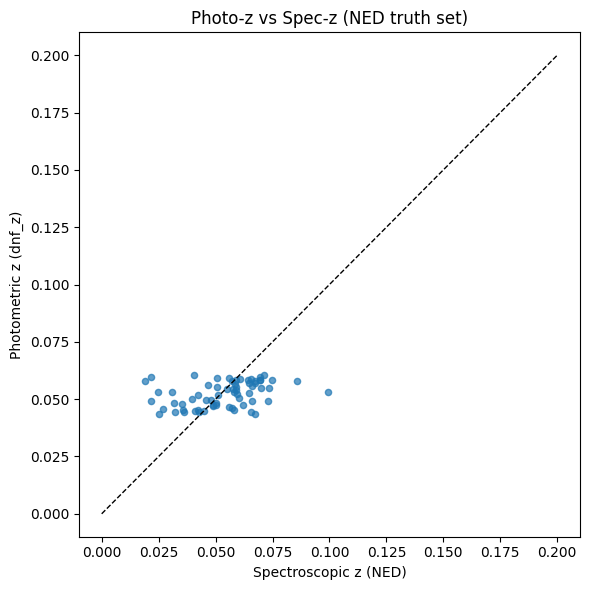

In [50]:
plt.figure(figsize=(6,6))
plt.scatter(spec["z_ned"], spec["dnf_z"], s=20, alpha=0.7)
plt.plot([0, 0.2], [0, 0.2], color="black", linestyle="--", linewidth=1)
plt.xlabel("Spectroscopic z (NED)")
plt.ylabel("Photometric z (dnf_z)")
plt.title("Photo-z vs Spec-z (NED truth set)")
plt.tight_layout()
plt.show()

In [51]:
spec["dz"] = spec["dnf_z"] - spec["z_ned"]
spec["abs_dz"] = spec["dz"].abs()
spec["dz_over_1pz"] = spec["dz"] / (1 + spec["z_ned"])

print("Median |dnf_z − z_spec|:", spec["abs_dz"].median())
print("90th percentile |dnf_z − z_spec|:", spec["abs_dz"].quantile(0.90))
print("Median |dz|/(1+z):", spec["dz_over_1pz"].abs().median())

Median |dnf_z − z_spec|: 0.009583312999999996
90th percentile |dnf_z − z_spec|: 0.0238016038
Median |dz|/(1+z): 0.009157424213353797


In [52]:
bad_abs = spec[spec["abs_dz"] > 0.1]
bad_frac = spec[spec["dz_over_1pz"].abs() > 0.15]

print("Absolute outliers (|dz| > 0.1):", len(bad_abs))
print("Fractional outliers (|dz|/(1+z) > 0.15):", len(bad_frac))

bad_abs[["coadd_object_id","dnf_z","z_ned","abs_dz"]].head()

Absolute outliers (|dz| > 0.1): 0
Fractional outliers (|dz|/(1+z) > 0.15): 0


,coadd_object_id,dnf_z,z_ned,abs_dz


In [53]:
implausible = spec[(spec["z_ned"] < 0) | (spec["z_ned"] > 0.3)]

print("Implausible spec-z for GW190814:", len(implausible))
implausible[["coadd_object_id","z_ned","dnf_z","ned_name"]]

Implausible spec-z for GW190814: 0


,coadd_object_id,z_ned,dnf_z,ned_name


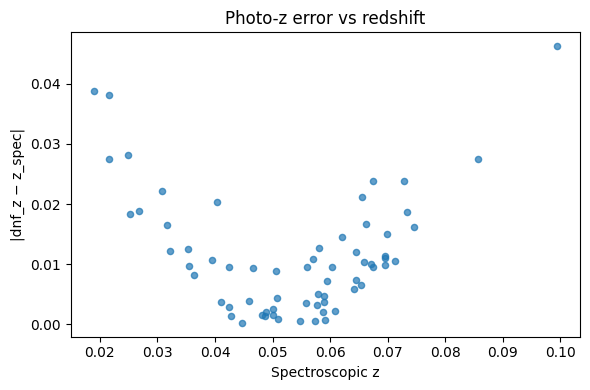

In [54]:
plt.figure(figsize=(6,4))
plt.scatter(spec["z_ned"], spec["abs_dz"], s=20, alpha=0.7)
plt.xlabel("Spectroscopic z")
plt.ylabel("|dnf_z − z_spec|")
plt.title("Photo-z error vs redshift")
plt.tight_layout()
plt.show()

In [55]:
!pip -q install pyvo astropy pandas numpy

import numpy as np
import pandas as pd
import pyvo as vo
from astropy.coordinates import SkyCoord
import astropy.units as u

In [57]:
GAL_FILE = "KEPT_OBJECTS_489.csv"

gal = pd.read_csv(GAL_FILE)
print("Galaxy rows:", len(gal))
gal_sky = SkyCoord(gal["ra"].values*u.deg, gal["dec"].values*u.deg, frame="icrs")

Galaxy rows: 478


In [58]:
svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

adql = f"""
SELECT ra, dec,
       parallax, parallax_error,
       pmra, pmra_error,
       pmdec, pmdec_error,
       phot_g_mean_mag
FROM gaia_dr3.gaia_source
WHERE ra BETWEEN {ra_min} AND {ra_max}
  AND dec BETWEEN {dec_min} AND {dec_max}
"""

print("Querying Gaia DR3 in patch (this can take a bit)...")
gaia = svc.search(adql).to_table().to_pandas()
print("Gaia rows in patch:", len(gaia))
gaia.head()

Querying Gaia DR3 in patch (this can take a bit)...
Gaia rows in patch: 77571


,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag
0,10.245251,-27.320145,4.503970,0.308881,9.320916,0.320317,22.777187,0.316370,19.219776
1,10.270006,-27.320741,0.056168,0.345809,-0.920814,0.363394,0.091194,0.350420,19.437714
2,10.266228,-27.306785,1.075754,0.050738,8.471269,0.046750,-13.789134,0.050629,15.786174
3,10.277242,-27.312775,0.465892,0.118876,1.416645,0.115652,-1.121080,0.113955,17.689524
4,10.268980,-27.304443,NaN,NaN,NaN,NaN,NaN,NaN,21.600849


In [59]:
gaia = gaia.dropna(subset=["ra","dec"]).copy()
gaia_sky = SkyCoord(gaia["ra"].values*u.deg, gaia["dec"].values*u.deg, frame="icrs")

idx, sep2d, _ = gal_sky.match_to_catalog_sky(gaia_sky)

match_radius = 1.0 * u.arcsec
m = sep2d < match_radius

print("Galaxies with a Gaia counterpart within 1 arcsec:", int(m.sum()))

Galaxies with a Gaia counterpart within 1 arcsec: 160


In [60]:
gal2 = gal.copy()
gal2["gaia_match"] = False
gal2["gaia_sep_arcsec"] = np.nan

# Gaia columns to attach
for c in ["parallax","parallax_error","pmra","pmra_error","pmdec","pmdec_error","phot_g_mean_mag"]:
    gal2[c] = np.nan

gal2.loc[m, "gaia_match"] = True
gal2.loc[m, "gaia_sep_arcsec"] = sep2d[m].to(u.arcsec).value

# attach Gaia values for matched
gaia_m = gaia.iloc[idx[m]].reset_index(drop=True)

gal2.loc[m, "parallax"] = gaia_m["parallax"].values
gal2.loc[m, "parallax_error"] = gaia_m["parallax_error"].values
gal2.loc[m, "pmra"] = gaia_m["pmra"].values
gal2.loc[m, "pmra_error"] = gaia_m["pmra_error"].values
gal2.loc[m, "pmdec"] = gaia_m["pmdec"].values
gal2.loc[m, "pmdec_error"] = gaia_m["pmdec_error"].values
gal2.loc[m, "phot_g_mean_mag"] = gaia_m["phot_g_mean_mag"].values

# significance tests
gal2["parallax_snr"] = gal2["parallax"] / gal2["parallax_error"]
gal2["pm_tot"] = np.sqrt(gal2["pmra"]**2 + gal2["pmdec"]**2)
gal2["pm_tot_err"] = np.sqrt(gal2["pmra_error"]**2 + gal2["pmdec_error"]**2)
gal2["pm_snr"] = gal2["pm_tot"] / gal2["pm_tot_err"]

# veto rule (conservative)
SIGMA = 5.0
gal2["gaia_star_veto"] = (
    gal2["gaia_match"] &
    (
        (gal2["parallax_snr"].abs() > SIGMA) |
        (gal2["pm_snr"].abs() > SIGMA)
    )
)

print("Gaia matches:", int(gal2["gaia_match"].sum()))
print("Flagged as stars by Gaia veto:", int(gal2["gaia_star_veto"].sum()))

Gaia matches: 160
Flagged as stars by Gaia veto: 109


In [61]:
gal2.to_csv("GW190814_478_with_gaia_veto.csv", index=False)
print("Saved GW190814_478_with_gaia_veto.csv")

# A convenient list of the vetoed objects (likely stars)
vetoed = gal2[gal2["gaia_star_veto"]].copy()
vetoed.to_csv("GW190814_gaia_vetoed_objects.csv", index=False)
print("Saved GW190814_gaia_vetoed_objects.csv with", len(vetoed), "rows")

Saved GW190814_478_with_gaia_veto.csv
Saved GW190814_gaia_vetoed_objects.csv with 109 rows


In [64]:
import pandas as pd

GAIA_FILE = "GW190814_478_with_gaia_veto.csv"        # <-- change if needed
NED_FILE  = "KEPT_OBJECTS_489_with_specz.csv"        # <-- change if needed

gaia = pd.read_csv(GAIA_FILE)
ned  = pd.read_csv(NED_FILE)

# Keep minimal columns
gaia = gaia[["coadd_object_id", "gaia_star_veto", "gaia_sep_arcsec"]].copy()

# NED file could have z_spec or z_ned depending on your write-back
zcol = None
for c in ["z_spec", "z_ned"]:
    if c in ned.columns:
        zcol = c
        break
if zcol is None:
    raise ValueError("NED file doesn't contain z_spec or z_ned. Columns are: " + str(ned.columns.tolist()))

ned["has_specz"] = ned[zcol].notna()

# Merge
m = ned.merge(gaia, on="coadd_object_id", how="left")

# If an object wasn’t in Gaia match table, gaia_star_veto will be NaN -> treat as False
m["gaia_star_veto"] = m["gaia_star_veto"].fillna(False)

overlap = m[(m["gaia_star_veto"] == True) & (m["has_specz"] == True)].copy()

print("Total NED spec-z:", int(m["has_specz"].sum()))
print("Total Gaia vetoes (within this merged set):", int(m["gaia_star_veto"].sum()))
print("Overlap (Gaia veto AND NED spec-z):", len(overlap))

# Show overlap cases if any
if len(overlap) > 0:
    cols = ["coadd_object_id", zcol, "dnf_z", "gaia_sep_arcsec", "ned_name", "ned_type"]
    cols = [c for c in cols if c in overlap.columns]
    display(overlap[cols].sort_values("gaia_sep_arcsec").head(30))


Total NED spec-z: 65
Total Gaia vetoes (within this merged set): 109
Overlap (Gaia veto AND NED spec-z): 0


In [66]:
# Ensure best redshift column exists (use whatever spec-z column is present)
if "z_best" not in gal.columns:
    spec_col = None
    for c in ["z_spec", "z_ned"]:
        if c in gal.columns:
            spec_col = c
            break

    if spec_col is None:
        # No spec-z column available in this file; fall back to photo-z only
        gal["z_best"] = gal["dnf_z"]
        gal["has_specz"] = False
        print("No spec-z column found; z_best set to dnf_z for all rows.")
    else:
        gal["z_best"] = gal[spec_col].where(gal[spec_col].notna(), gal["dnf_z"])
        gal["has_specz"] = gal[spec_col].notna()
        print(f"Using {spec_col} as spec-z column.")

No spec-z column found; z_best set to dnf_z for all rows.


In [67]:
import pandas as pd
import numpy as np

GAIA_FILE = "GW190814_478_with_gaia_veto.csv"
NED_FILE  = "NED_bulk_improved.csv"
OUT_FILE  = "GW190814_369_genuine_galaxies_with_specz.csv"

gaia = pd.read_csv(GAIA_FILE)
ned  = pd.read_csv(NED_FILE)

print("Gaia table rows:", len(gaia))
print("NED table rows:", len(ned))

# ---- Keep only the key NED columns (ignore everything else) ----
# NED file should have at least coadd_object_id and z_ned
need = ["coadd_object_id", "z_ned"]
missing_cols = [c for c in need if c not in ned.columns]
if missing_cols:
    raise ValueError(f"NED file is missing required columns: {missing_cols}. Found: {ned.columns.tolist()}")

ned_keep_cols = [c for c in ["coadd_object_id", "z_ned", "ned_name", "ned_type", "ned_sep_arcsec", "ned_radius_used_arcsec"] if c in ned.columns]
ned = ned[ned_keep_cols].copy()

# ---- Merge NED onto Gaia table ----
m = gaia.merge(ned, on="coadd_object_id", how="left")

# ---- Compute has_specz based on NED ----
m["has_specz"] = m["z_ned"].notna()

print("Spec-z (NED) found in merged table:", int(m["has_specz"].sum()))

# ---- Apply Gaia star veto to get your genuine galaxy sample ----
if "gaia_star_veto" not in m.columns:
    raise ValueError("Gaia file does not contain gaia_star_veto column.")

gal = m[~m["gaia_star_veto"]].copy()

print("Final genuine galaxies:", len(gal))
print("Spec-z in final genuine sample:", int(gal["has_specz"].sum()))

# ---- Build z_best ----
if "dnf_z" not in gal.columns:
    raise ValueError("Expected dnf_z (photo-z) in the Gaia table but did not find it.")

gal["z_best"] = gal["z_ned"].where(gal["z_ned"].notna(), gal["dnf_z"])

# ---- Save ----
gal.to_csv(OUT_FILE, index=False)
print("Saved:", OUT_FILE)

Gaia table rows: 478
NED table rows: 478
Spec-z (NED) found in merged table: 65
Final genuine galaxies: 369
Spec-z in final genuine sample: 65
Saved: GW190814_369_genuine_galaxies_with_specz.csv


Galaxy rows: 369
Spec-z count: 65
Querying Legacy DR10 tractor for flux_g/flux_r (may take a bit)...
Legacy rows in box: 4211270
Matches within 1 arcsec: 358 / 369
Final CMD sample size: 358
Saved: GW190814_CMD_369_zbest.csv


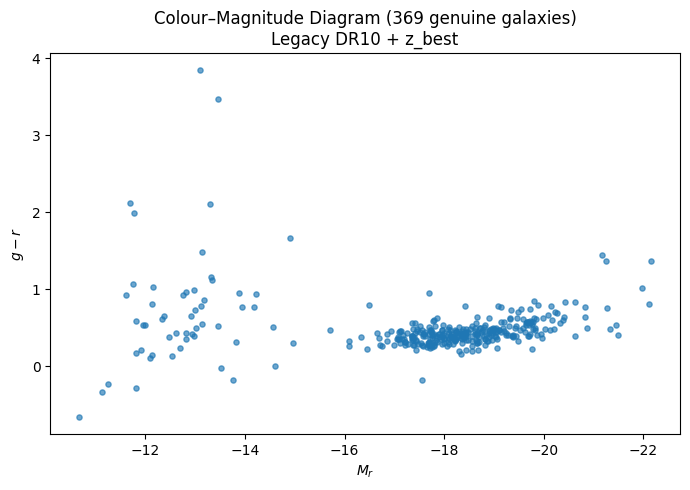

In [69]:
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg.split("==")[0].split(">=")[0])
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for p in ["pyvo", "astropy", "pandas", "numpy", "matplotlib"]:
    pip_install(p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyvo as vo

# ------------------------------------------------------------
# 1) Load your cleaned galaxy master table (369)
# ------------------------------------------------------------
gal = pd.read_csv("GW190814_369_genuine_galaxies_with_specz.csv")
print("Galaxy rows:", len(gal))
print("Spec-z count:", int(gal["has_specz"].sum()) if "has_specz" in gal.columns else "n/a")

# Make sure z_best exists
if "z_best" not in gal.columns:
    raise RuntimeError("z_best column not found. (Should exist in the 369 file.)")

gal_sky = SkyCoord(gal["ra"].values*u.deg, gal["dec"].values*u.deg, frame="icrs")

# RA/Dec box (same as your 90% rectangle)
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

# ------------------------------------------------------------
# 2) Query Legacy DR10 tractor for g/r fluxes in this box
#    (fluxes are in nanomaggies)
# ------------------------------------------------------------
svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

adql = f"""
SELECT ra, dec, flux_g, flux_r
FROM ls_dr10.tractor
WHERE ra BETWEEN {ra_min} AND {ra_max}
  AND dec BETWEEN {dec_min} AND {dec_max}
  AND flux_g > 0
  AND flux_r > 0
"""

print("Querying Legacy DR10 tractor for flux_g/flux_r (may take a bit)...")
leg = svc.search(adql).to_table().to_pandas()
print("Legacy rows in box:", len(leg))

leg_sky = SkyCoord(leg["ra"].values*u.deg, leg["dec"].values*u.deg, frame="icrs")

# ------------------------------------------------------------
# 3) Crossmatch 369 galaxies ↔ Legacy sources
# ------------------------------------------------------------
idx, sep, _ = gal_sky.match_to_catalog_sky(leg_sky)
match_radius = 1.0 * u.arcsec
m = sep < match_radius

print("Matches within 1 arcsec:", int(m.sum()), "/", len(gal))

gal_m = gal[m].reset_index(drop=True)
leg_m = leg.iloc[idx[m]].reset_index(drop=True)

merged = pd.concat([gal_m, leg_m[["flux_g","flux_r"]]], axis=1)

# ------------------------------------------------------------
# 4) Compute g, r, g-r, and M_r using z_best
# ------------------------------------------------------------
# Convert nanomaggies → AB mag
merged["g"] = 22.5 - 2.5 * np.log10(merged["flux_g"])
merged["r"] = 22.5 - 2.5 * np.log10(merged["flux_r"])
merged["g_r"] = merged["g"] - merged["r"]

# Absolute M_r via distance modulus using z_best
DL_pc = cosmo.luminosity_distance(merged["z_best"]).to("pc").value
merged["M_r"] = merged["r"] - 5 * np.log10(DL_pc / 10.0)

print("Final CMD sample size:", len(merged))

# ------------------------------------------------------------
# 5) Save CSV of CMD quantities
# ------------------------------------------------------------
cmd_cols = [
    "coadd_object_id", "ra", "dec",
    "dnf_z", "z_ned", "has_specz", "z_best",
    "g", "r", "g_r", "M_r",
    "flux_g", "flux_r"
]
cmd_cols = [c for c in cmd_cols if c in merged.columns]

merged[cmd_cols].to_csv("GW190814_CMD_369_zbest.csv", index=False)
print("Saved: GW190814_CMD_369_zbest.csv")

# ------------------------------------------------------------
# 6) Plot CMD
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(merged["M_r"], merged["g_r"], s=14, alpha=0.65)
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g-r$")
plt.title("Colour–Magnitude Diagram (369 genuine galaxies)\nLegacy DR10 + z_best")
plt.tight_layout()
plt.show()

In [70]:
spec = gal[gal["has_specz"] == True].copy()
print("Spec-z galaxies:", len(spec))

Spec-z galaxies: 65


In [72]:
print(gal.columns.tolist())

['coadd_object_id', 'ra', 'dec', 'mag_auto_i', 'flags_i', 'dnf_z', 'wavg_spread_model_z', 'wavg_spreaderr_model_z', 'spread_model_z', 'spreaderr_model_z', 'gaia_match', 'gaia_sep_arcsec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'phot_g_mean_mag', 'parallax_snr', 'pm_tot', 'pm_tot_err', 'pm_snr', 'gaia_star_veto', 'z_ned', 'ned_name', 'ned_type', 'ned_sep_arcsec', 'ned_radius_used_arcsec', 'has_specz', 'z_best']


In [73]:
!pip -q install pyvo astropy pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvo as vo

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

In [74]:
GAL_FILE = "GW190814_369_genuine_galaxies_with_specz.csv"
gal = pd.read_csv(GAL_FILE)

print("Galaxy rows:", len(gal))
print("Spec-z count:", int(gal["has_specz"].sum()) if "has_specz" in gal.columns else "n/a")

# Basic sanity
required = {"coadd_object_id","ra","dec","z_best"}
missing = required - set(gal.columns)
if missing:
    raise ValueError(f"Missing required columns in {GAL_FILE}: {missing}")

gal_sky = SkyCoord(gal["ra"].values*u.deg, gal["dec"].values*u.deg, frame="icrs")

Galaxy rows: 369
Spec-z count: 65


In [75]:
ra_min, ra_max = 10.2392578125, 14.8974609375
dec_min, dec_max = -27.3215904756, -22.2256480484

svc = vo.dal.TAPService("https://datalab.noirlab.edu/tap")

adql = f"""
SELECT ra, dec, flux_g, flux_r
FROM ls_dr10.tractor
WHERE ra BETWEEN {ra_min} AND {ra_max}
  AND dec BETWEEN {dec_min} AND {dec_max}
  AND flux_g > 0
  AND flux_r > 0
"""

print("Querying Legacy DR10 tractor (flux_g, flux_r) in patch…")
leg = svc.search(adql).to_table().to_pandas()
print("Legacy rows returned:", len(leg))

leg_sky = SkyCoord(leg["ra"].values*u.deg, leg["dec"].values*u.deg, frame="icrs")

Querying Legacy DR10 tractor (flux_g, flux_r) in patch…
Legacy rows returned: 4211270


In [76]:
idx, sep2d, _ = gal_sky.match_to_catalog_sky(leg_sky)

match_radius = 1.0 * u.arcsec
m = sep2d < match_radius

print("Matched galaxies within 1 arcsec:", int(m.sum()), "/", len(gal))

gal_m = gal[m].reset_index(drop=True)
leg_m = leg.iloc[idx[m]].reset_index(drop=True)

merged = pd.concat([gal_m, leg_m[["flux_g","flux_r"]]], axis=1)
merged["legacy_sep_arcsec"] = sep2d[m].to(u.arcsec).value

print("Merged rows:", len(merged))

Matched galaxies within 1 arcsec: 358 / 369
Merged rows: 358


In [77]:
# Convert nanomaggies -> AB mag
merged["g"] = 22.5 - 2.5 * np.log10(merged["flux_g"])
merged["r"] = 22.5 - 2.5 * np.log10(merged["flux_r"])
merged["g_r"] = merged["g"] - merged["r"]

# Absolute Mr using z_best
DL_pc = cosmo.luminosity_distance(merged["z_best"]).to("pc").value
merged["Mr"] = merged["r"] - 5 * np.log10(DL_pc / 10.0)

print(merged[["g","r","g_r","Mr"]].describe())

                g           r         g_r          Mr
count  358.000000  358.000000  358.000000  358.000000
mean    19.733187   19.242970    0.490216  -17.671674
std      2.344132    2.268644    0.364182    2.313173
min     15.766381   14.753913   -0.658066  -22.160561
25%     18.367284   17.935680    0.352487  -19.030918
50%     19.146338   18.755451    0.426624  -18.193509
75%     19.857817   19.450956    0.528627  -17.357871
max     27.995285   26.524918    3.838680  -10.659988


In [78]:
OUT_CMD = "GW190814_CMD_369_with_legacy_photometry.csv"

cols = [
    "coadd_object_id","ra","dec","dnf_z","z_ned","has_specz","z_best",
    "flux_g","flux_r","g","r","g_r","Mr","legacy_sep_arcsec"
]
cols = [c for c in cols if c in merged.columns]

merged[cols].to_csv(OUT_CMD, index=False)
print("Saved:", OUT_CMD)

Saved: GW190814_CMD_369_with_legacy_photometry.csv


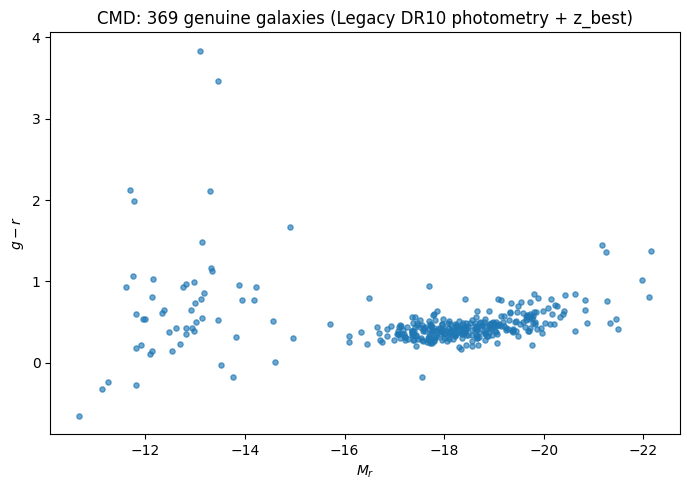

In [79]:
plt.figure(figsize=(7,5))
plt.scatter(merged["Mr"], merged["g_r"], s=14, alpha=0.65)
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("CMD: 369 genuine galaxies (Legacy DR10 photometry + z_best)")
plt.tight_layout()
plt.show()

Spec-z CMD sample: 65


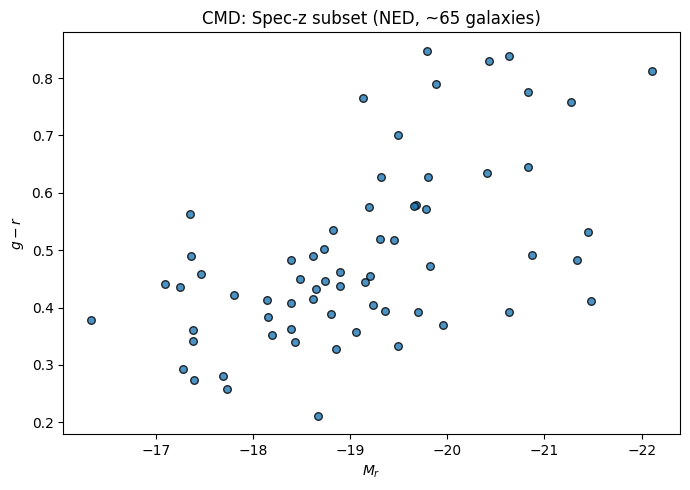

In [80]:
spec = merged[merged["has_specz"] == True].copy()
print("Spec-z CMD sample:", len(spec))

plt.figure(figsize=(7,5))
plt.scatter(spec["Mr"], spec["g_r"], s=30, alpha=0.8, edgecolor="k")
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("CMD: Spec-z subset (NED, ~65 galaxies)")
plt.tight_layout()
plt.show()

Spec-z CMD sample: 65


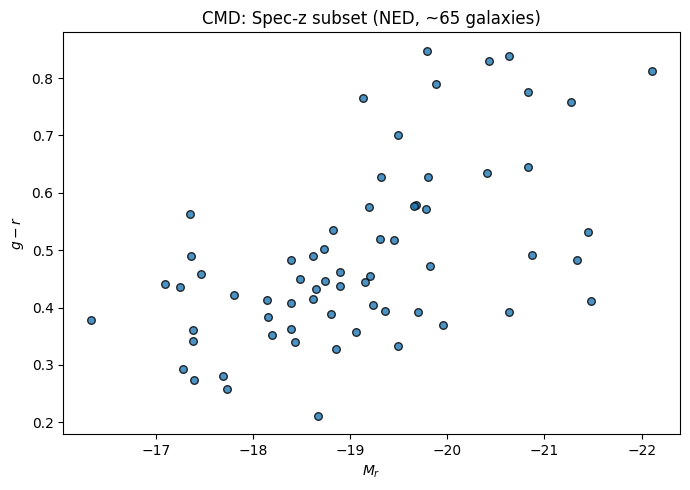

In [81]:
spec = merged[merged["has_specz"] == True].copy()
print("Spec-z CMD sample:", len(spec))

plt.figure(figsize=(7,5))
plt.scatter(spec["Mr"], spec["g_r"], s=30, alpha=0.8, edgecolor="k")
plt.gca().invert_xaxis()
plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("CMD: Spec-z subset (NED, ~65 galaxies)")
plt.tight_layout()
plt.show()

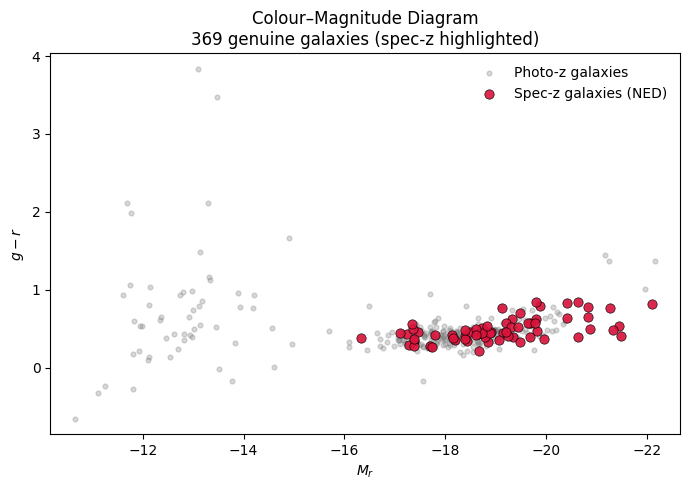

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Background: all genuine galaxies
plt.scatter(
    merged["Mr"], merged["g_r"],
    s=12,
    alpha=0.3,
    color="gray",
    label="Photo-z galaxies"
)

# Foreground: spectroscopic subset
plt.scatter(
    spec["Mr"], spec["g_r"],
    s=45,
    alpha=0.9,
    color="crimson",
    edgecolor="black",
    linewidth=0.5,
    label="Spec-z galaxies (NED)"
)

# Fix axes using full sample
Mr_min, Mr_max = merged["Mr"].min(), merged["Mr"].max()
gr_min, gr_max = merged["g_r"].min(), merged["g_r"].max()

plt.xlim(Mr_max + 0.5, Mr_min - 0.5)  # inverted x-axis
plt.ylim(gr_min - 0.2, gr_max + 0.2)

plt.xlabel(r"$M_r$")
plt.ylabel(r"$g - r$")
plt.title("Colour–Magnitude Diagram\n369 genuine galaxies (spec-z highlighted)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()